# REGRESSION:

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import math

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [ ]:
from google.colab import files
uploaded = files.upload()

df_aqi = pd.read_csv("ai_for_society_aqi_dataset.csv")
df_credit = pd.read_csv("banking_credit_scoring_regression.csv")

datasets = {
    "AQI Dataset": df_aqi,
    "Credit Score Dataset": df_credit
}

Saving banking_credit_scoring_regression.csv to banking_credit_scoring_regression.csv
Saving ai_for_society_aqi_dataset.csv to ai_for_society_aqi_dataset.csv


{'AQI Dataset':      Temperature  Humidity  WindSpeed  TrafficDensity  IndustrialEmission  AQI
 0           34.9      48.9       16.7               4                   8  141
 1           37.0      45.8        1.9              10                   1  250
 2           26.9      63.9       14.8               3                   2   43
 3           28.6      44.5       19.2               4                   1    0
 4           24.8      58.9       13.6               4                   9   96
 ..           ...       ...        ...             ...                 ...  ...
 995         31.7      70.7        2.7               4                   9  267
 996         28.6      75.2       12.6              10                  10  290
 997         34.9      30.8        6.0               6                   4  176
 998         24.5      76.7        0.4              10                   8  328
 999         26.9      70.5       17.8               7                   4  130
 
 [1000 rows x 6 columns

In [ ]:
for name, df in datasets.items():
    print("\n============================")
    print(name)
    print("============================")
    print(df.head())
    print("\nShape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    # Check missing values and fill with numeric means for both datasets
    print("\nMissing values before fill:")
    print(df.isnull().sum())

    # Fill numeric columns with mean (keeps non-numeric unchanged)
    df_filled = df.fillna(df.mean(numeric_only=True))

    print("\nMissing values after fill:")
    print(df_filled.isnull().sum())

    # overwrite in datasets dict so later cells use cleaned df
    datasets[name] = df_filled




AQI Dataset
   Temperature  Humidity  WindSpeed  TrafficDensity  IndustrialEmission  AQI
0         34.9      48.9       16.7               4                   8  141
1         37.0      45.8        1.9              10                   1  250
2         26.9      63.9       14.8               3                   2   43
3         28.6      44.5       19.2               4                   1    0
4         24.8      58.9       13.6               4                   9   96

Shape: (1000, 6)

Columns: ['Temperature', 'Humidity', 'WindSpeed', 'TrafficDensity', 'IndustrialEmission', 'AQI']

Missing values before fill:
Temperature           0
Humidity              0
WindSpeed             0
TrafficDensity        0
IndustrialEmission    0
AQI                   0
dtype: int64

Missing values after fill:
Temperature           0
Humidity              0
WindSpeed             0
TrafficDensity        0
IndustrialEmission    0
AQI                   0
dtype: int64

Credit Score Dataset
   CustomerID  A

In [ ]:
targets = {}

for name, df in datasets.items():
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    target = numeric_cols[-1]
    targets[name] = target
    print(f"{name} → Target selected: {target}")

AQI Dataset → Target selected: AQI
Credit Score Dataset → Target selected: CreditScore


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

def preprocess(df):
    df_clean = df.copy()

    # Fill missing numeric values
    df_clean = df_clean.fillna(df_clean.mean(numeric_only=True))

    # Identify non-numeric columns
    nonnum_cols = df_clean.select_dtypes(exclude=['int64','float64']).columns.tolist()

    # Encode them safely
    if nonnum_cols:
        print("Encoding non-numeric columns:", nonnum_cols)
        encoder = OrdinalEncoder()
        df_clean[nonnum_cols] = encoder.fit_transform(df_clean[nonnum_cols].astype(str))

    return df_clean

In [ ]:
def visualize_dataset(df, target):
    print(f"\n### Visualizing Dataset — Target: {target}\n")

    # Only numeric columns for visualization
    numeric_df = df.select_dtypes(include=['int64','float64'])

    # Distribution of target
    plt.figure(figsize=(8,5))
    sns.histplot(numeric_df[target], kde=True)
    plt.title(f"Distribution of {target}")
    plt.show()

    # Scatterplots (other numeric columns vs target)
    feature_cols = [col for col in numeric_df.columns if col != target]

    n = len(feature_cols)
    cols = 3
    rows = math.ceil(n / cols)
    plt.figure(figsize=(cols*5, rows*4))

    for i, col in enumerate(feature_cols, start=1):
        plt.subplot(rows, cols, i)
        sns.scatterplot(x=numeric_df[col], y=numeric_df[target])
        plt.xlabel(col)
        plt.ylabel(target)
        plt.title(f"{col} vs {target}")

    plt.tight_layout()
    plt.show()

In [ ]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n===== {name} =====")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R²  :", r2)

    # Actual vs Predicted Plot
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=y_test, y=y_pred)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Actual vs Predicted — {name}")
    plt.show()

    # Residuals Distribution
    residuals = y_test - y_pred
    plt.figure(figsize=(6,5))
    sns.histplot(residuals, kde=True, color="red")
    plt.title(f"Residual Distribution — {name}")
    plt.show()

In [ ]:
def final_model_visualization(dataset_name, model_name, model, X_train, X_test, y_train, y_test):
    # Train model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n==================== {dataset_name} — {model_name} ====================\n")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R²  :", r2)

    # ---------- Actual vs Predicted (with diagonal) ----------
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=y_test, y=y_pred)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{dataset_name} — {model_name}\nActual vs Predicted (with 45° line)")
    plt.show()

    # ---------- Residual Distribution ----------
    residuals = y_test - y_pred
    plt.figure(figsize=(6,5))
    sns.histplot(residuals, kde=True, color='purple')
    plt.title(f"{dataset_name} — {model_name}\nResidual Distribution")
    plt.show()

    # ---------- Residuals vs Predicted ----------
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=y_pred, y=residuals)
    plt.axhline(0, color='black')
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(f"{dataset_name} — {model_name}\nResiduals vs Predicted")
    plt.show()

    print("\n")

# CLASSIFICATION:

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.preprocessing import OrdinalEncoder

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [4]:
uploaded = files.upload()

datasets = {
    "Heart Disease Dataset": pd.read_csv("ai_for_society_heart_disease_dataset.csv"),
    "Telecom Churn Dataset": pd.read_csv("ai_for_society_telecom_customer_churn_dataset.csv"),
    "Fraud Detection Dataset": pd.read_csv("banking_fraud_detection_dataset.csv"),
    "Loan Approval Dataset": pd.read_csv("banking_loan_approval_dataset.csv")
}


Saving banking_loan_approval_dataset.csv to banking_loan_approval_dataset (1).csv
Saving banking_fraud_detection_dataset.csv to banking_fraud_detection_dataset (1).csv
Saving ai_for_society_telecom_customer_churn_dataset.csv to ai_for_society_telecom_customer_churn_dataset (1).csv
Saving ai_for_society_heart_disease_dataset.csv to ai_for_society_heart_disease_dataset (1).csv


In [12]:
for name, df in datasets.items():
    print("\n==========================")
    print(name)
    print(df.shape)
    print(df.head())
    print(df.info())


Heart Disease Dataset
(1000, 7)
   Age   BMI  BloodPressure  Cholesterol  PhysicalActivity  Smoking  \
0   71  25.1            166          220               2.3        1   
1   34  30.8            143          280               0.3        1   
2   80  26.9            132          159               5.6        0   
3   40  27.7            172          247               0.4        0   
4   43  28.2            160          238               1.9        1   

   HeartDisease  
0             1  
1             0  
2             1  
3             1  
4             1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1000 non-null   int64  
 1   BMI               1000 non-null   float64
 2   BloodPressure     1000 non-null   int64  
 3   Cholesterol       1000 non-null   int64  
 4   PhysicalActivity  1000 non-null   float6

In [18]:
targets = {}

for name, df in datasets.items():
    # Choose Last column
    target = df.columns[-1]
    targets[name] = target
    # quick diagnostics
    unique_vals = df[target].nunique()
    print(f"{name} → Target selected: '{target}' (unique classes: {unique_vals})")

Heart Disease Dataset → Target selected: 'HeartDisease' (unique classes: 2)
Telecom Churn Dataset → Target selected: 'Churn' (unique classes: 2)
Fraud Detection Dataset → Target selected: 'Fraud' (unique classes: 2)
Loan Approval Dataset → Target selected: 'LoanApproved' (unique classes: 2)


In [14]:
def preprocess_classification(df, target):
    """
    - fills missing numeric and categorical values
    - encodes categorical features (excluding the target column)
    """
    df_clean = df.copy()

    # Fill numeric missing values
    df_clean = df_clean.fillna(df_clean.mean(numeric_only=True))

    # Fill categorical missing values (only for object columns other than target)
    for col in df_clean.select_dtypes(include=['object']).columns:
        if col == target:
            continue
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

    # Encode categorical columns except the target
    nonnum_cols = [c for c in df_clean.select_dtypes(include=['object','bool']).columns if c != target]
    if len(nonnum_cols) > 0:
        enc = OrdinalEncoder()
        df_clean[nonnum_cols] = enc.fit_transform(df_clean[nonnum_cols].astype(str))

    return df_clean

In [26]:
def visualize_classification(df, target):
    print(f"\n### Visualizing target: {target}\n")

    # Count plot for target balance
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[target])
    plt.title(f"Class Distribution — {target}")
    plt.show()


Preparing dataset: Heart Disease Dataset
Class distribution (train):
HeartDisease
1    509
0    291
Name: count, dtype: int64

### Visualizing target: HeartDisease



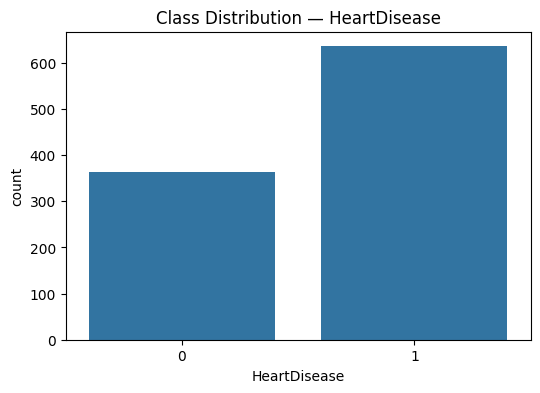


Preparing dataset: Telecom Churn Dataset
Class distribution (train):
Churn
0    422
1    378
Name: count, dtype: int64

### Visualizing target: Churn



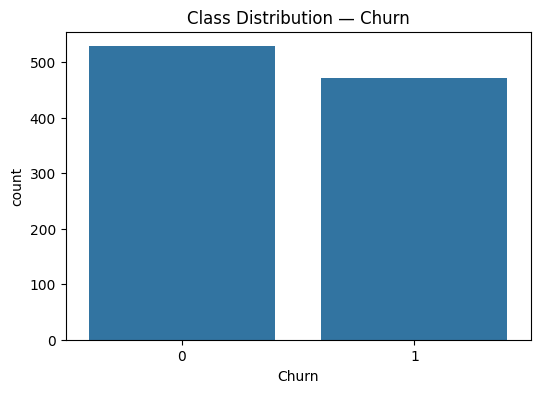


Preparing dataset: Fraud Detection Dataset
Class distribution (train):
Fraud
0    717
1     83
Name: count, dtype: int64

### Visualizing target: Fraud



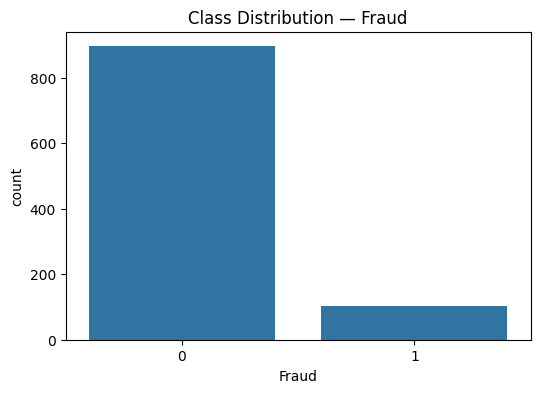


Preparing dataset: Loan Approval Dataset
Class distribution (train):
LoanApproved
0    440
1    360
Name: count, dtype: int64

### Visualizing target: LoanApproved



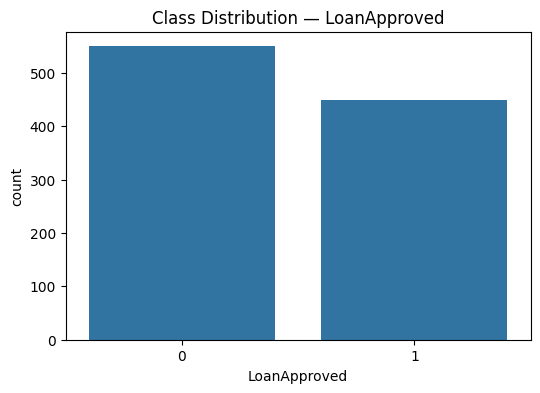

In [27]:
splits = {}

for name, df in datasets.items():
    print(f"\nPreparing dataset: {name}")

    # Target is last column
    target = targets[name]

    # Preprocess
    df_clean = preprocess_classification(df, target)

    # Ensure target is numeric (label encode if needed)
    if df_clean[target].dtype == 'object':
        le = LabelEncoder()
        df_clean[target] = le.fit_transform(df_clean[target].astype(str))

    # Prepare X, y
    X = df_clean.drop(columns=[target])
    y = df_clean[target].astype(int)

    # Train/test split (stratify for balanced classes)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y if y.nunique() > 1 else None
    )

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Store everything
    splits[name] = {
        "X_train": X_train,
        "X_test": X_test,
        "X_train_scaled": X_train_scaled,
        "X_test_scaled": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test
    }

    # Class Distribution Check
    print("Class distribution (train):")
    print(y_train.value_counts())

    # Visualize the cleaned dataset
    visualize_classification(df_clean, target)

In [23]:
def evaluate_classifier(model_name, model, X_train, X_test, y_train, y_test, dataset_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n========== {dataset_name} — {model_name} ==========")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
    plt.title(f"{dataset_name} — {model_name} (Confusion Matrix)")
    plt.show()

    # ROC Curve (for binary only)
    if len(np.unique(y_test)) == 2:
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:,1]
        else:
            y_prob = model.decision_function(X_test)

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)

        plt.plot(fpr, tpr)
        plt.plot([0,1],[0,1],'--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{dataset_name} — {model_name} (ROC Curve) AUC={auc:.3f}")
        plt.show()



=========== CLASSIFICATION MODELS ON: Heart Disease Dataset ===========


========== Heart Disease Dataset — KNN ==========
              precision    recall  f1-score   support

           0       0.39      0.36      0.37        73
           1       0.65      0.68      0.66       127

    accuracy                           0.56       200
   macro avg       0.52      0.52      0.52       200
weighted avg       0.55      0.56      0.56       200



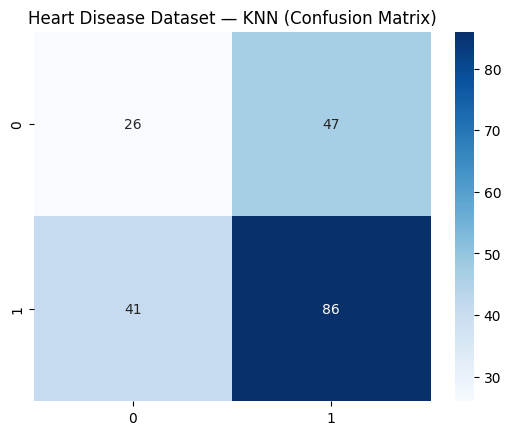

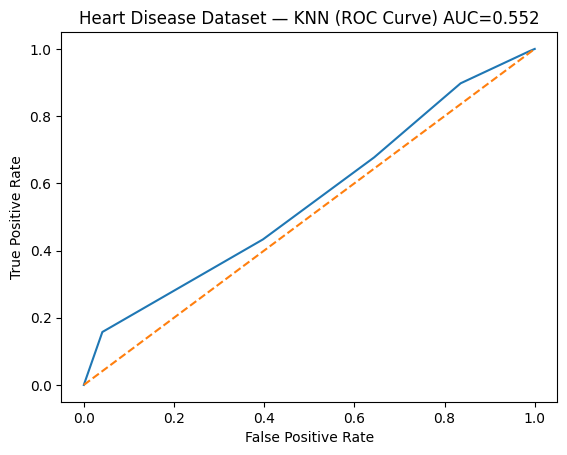


========== Heart Disease Dataset — Decision Tree ==========
              precision    recall  f1-score   support

           0       0.47      0.41      0.44        73
           1       0.68      0.73      0.71       127

    accuracy                           0.61       200
   macro avg       0.58      0.57      0.57       200
weighted avg       0.61      0.61      0.61       200



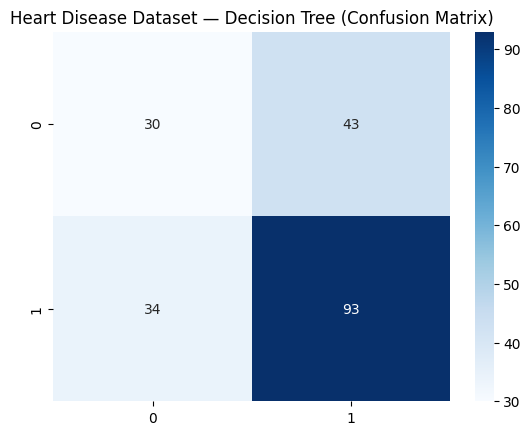

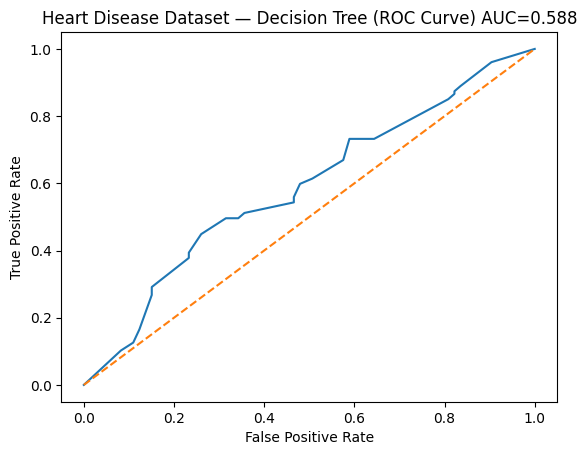


========== Heart Disease Dataset — Random Forest ==========
              precision    recall  f1-score   support

           0       0.47      0.37      0.41        73
           1       0.68      0.76      0.71       127

    accuracy                           0.61       200
   macro avg       0.57      0.56      0.56       200
weighted avg       0.60      0.61      0.60       200



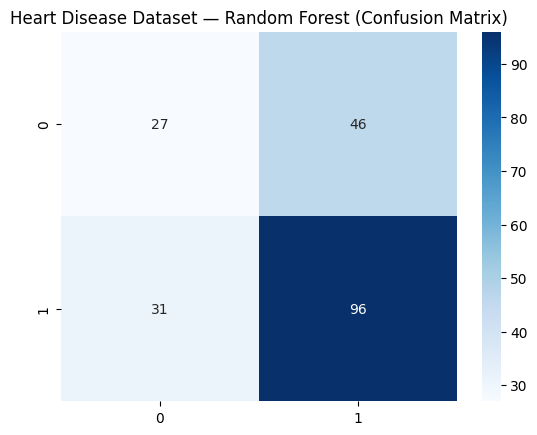

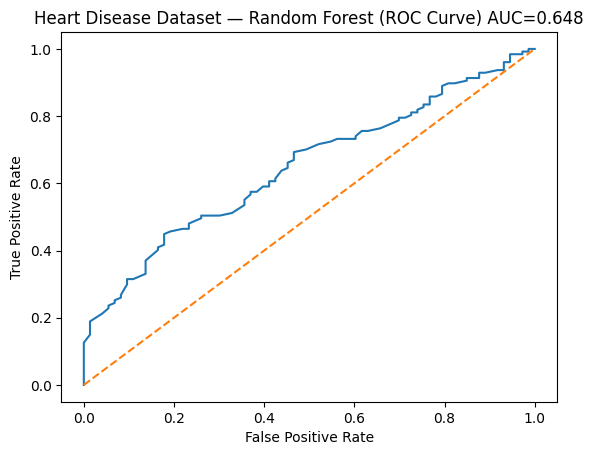



=========== CLASSIFICATION MODELS ON: Telecom Churn Dataset ===========


========== Telecom Churn Dataset — KNN ==========
              precision    recall  f1-score   support

           0       0.63      0.61      0.62       106
           1       0.58      0.60      0.59        94

    accuracy                           0.60       200
   macro avg       0.60      0.60      0.60       200
weighted avg       0.61      0.60      0.61       200



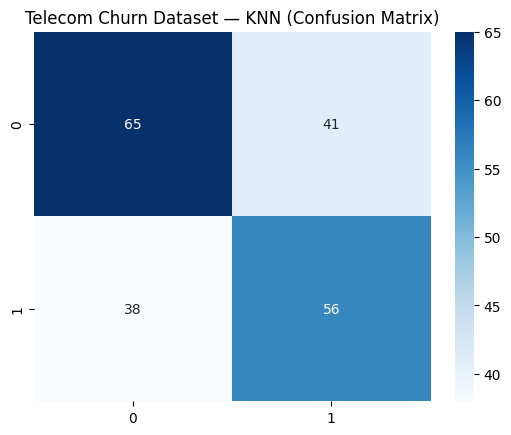

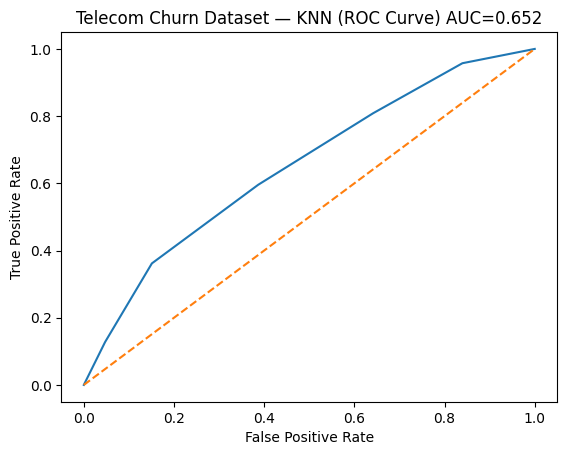


========== Telecom Churn Dataset — Decision Tree ==========
              precision    recall  f1-score   support

           0       0.64      0.71      0.67       106
           1       0.63      0.55      0.59        94

    accuracy                           0.64       200
   macro avg       0.63      0.63      0.63       200
weighted avg       0.63      0.64      0.63       200



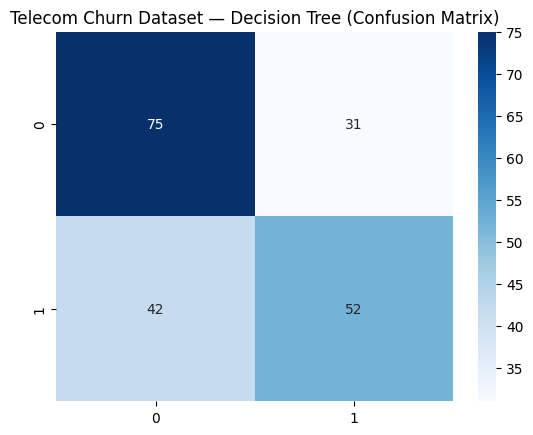

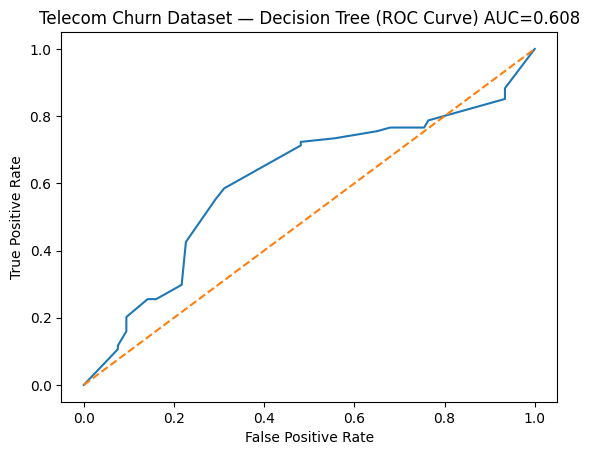


========== Telecom Churn Dataset — Random Forest ==========
              precision    recall  f1-score   support

           0       0.65      0.70      0.68       106
           1       0.63      0.59      0.61        94

    accuracy                           0.65       200
   macro avg       0.64      0.64      0.64       200
weighted avg       0.64      0.65      0.64       200



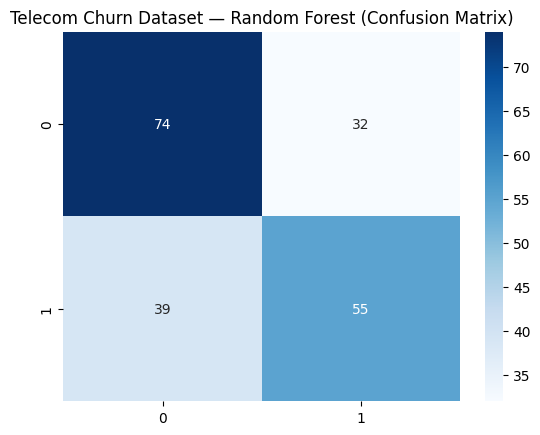

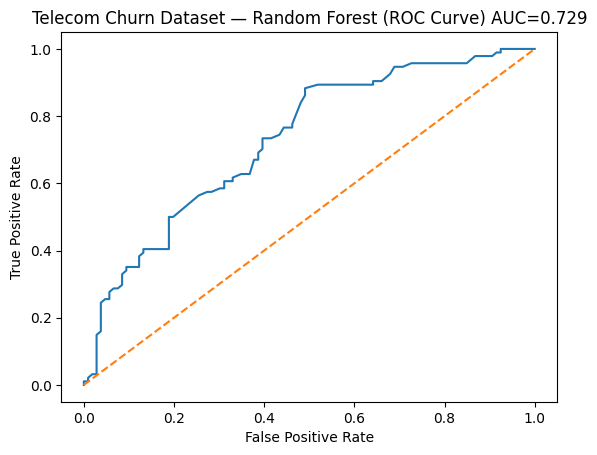



=========== CLASSIFICATION MODELS ON: Fraud Detection Dataset ===========


========== Fraud Detection Dataset — KNN ==========
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       179
           1       0.33      0.10      0.15        21

    accuracy                           0.89       200
   macro avg       0.62      0.54      0.54       200
weighted avg       0.84      0.89      0.86       200



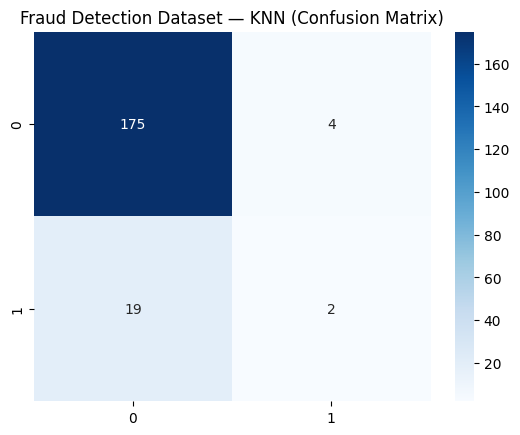

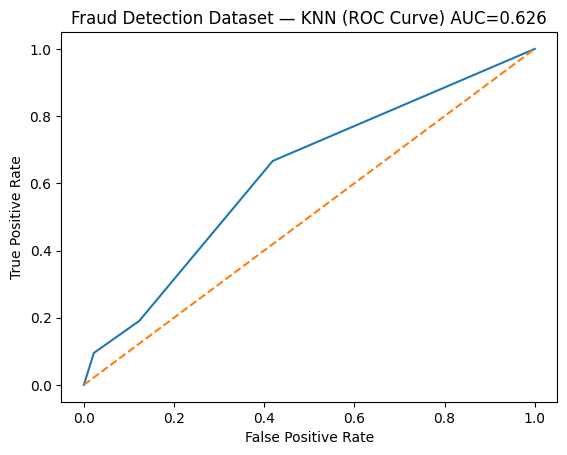


========== Fraud Detection Dataset — Decision Tree ==========
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       179
           1       0.33      0.14      0.20        21

    accuracy                           0.88       200
   macro avg       0.62      0.55      0.57       200
weighted avg       0.85      0.88      0.86       200



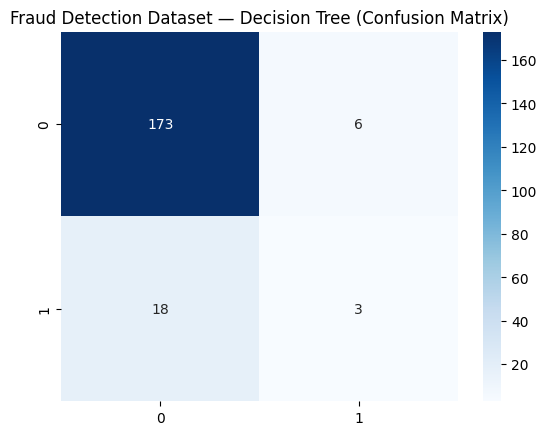

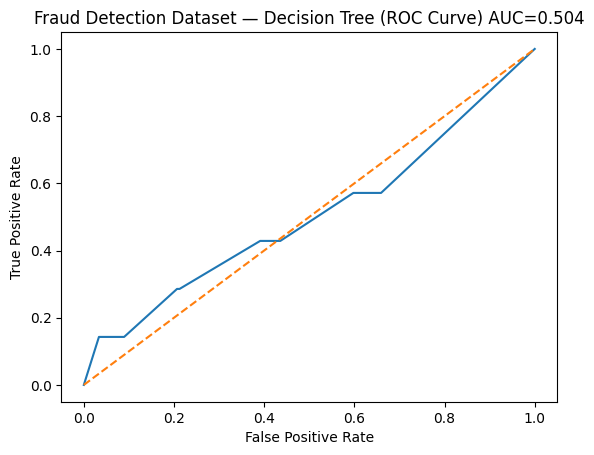


========== Fraud Detection Dataset — Random Forest ==========
              precision    recall  f1-score   support

           0       0.90      1.00      0.94       179
           1       0.00      0.00      0.00        21

    accuracy                           0.90       200
   macro avg       0.45      0.50      0.47       200
weighted avg       0.80      0.90      0.85       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


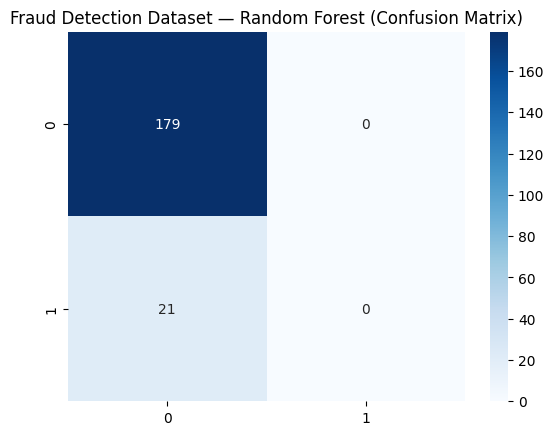

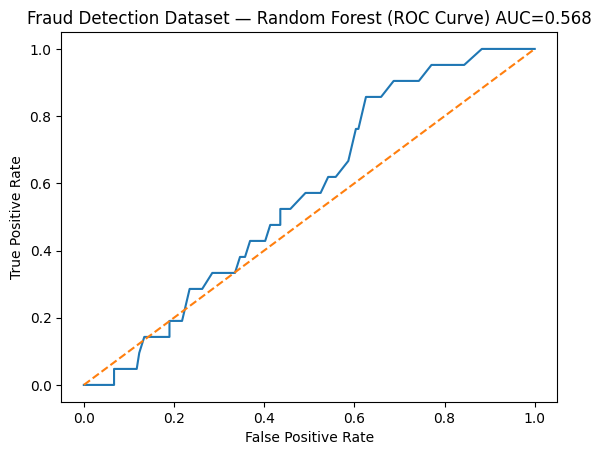



=========== CLASSIFICATION MODELS ON: Loan Approval Dataset ===========


========== Loan Approval Dataset — KNN ==========
              precision    recall  f1-score   support

           0       0.66      0.67      0.67       110
           1       0.59      0.58      0.58        90

    accuracy                           0.63       200
   macro avg       0.63      0.63      0.63       200
weighted avg       0.63      0.63      0.63       200



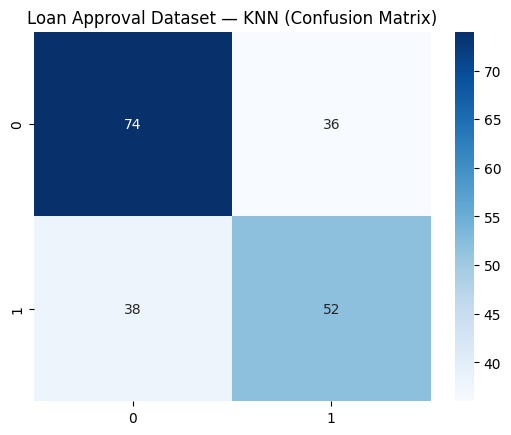

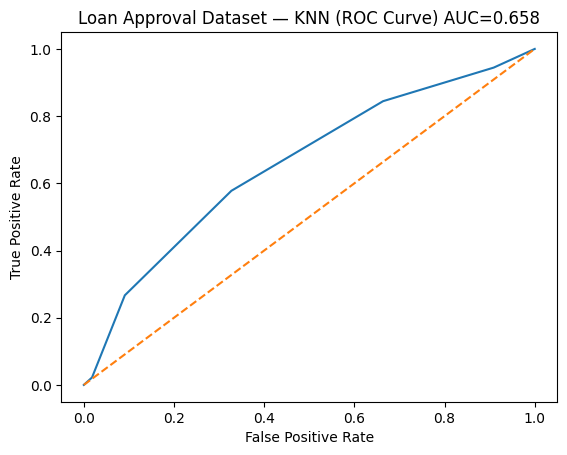


========== Loan Approval Dataset — Decision Tree ==========
              precision    recall  f1-score   support

           0       0.69      0.82      0.75       110
           1       0.71      0.54      0.62        90

    accuracy                           0.69       200
   macro avg       0.70      0.68      0.68       200
weighted avg       0.70      0.69      0.69       200



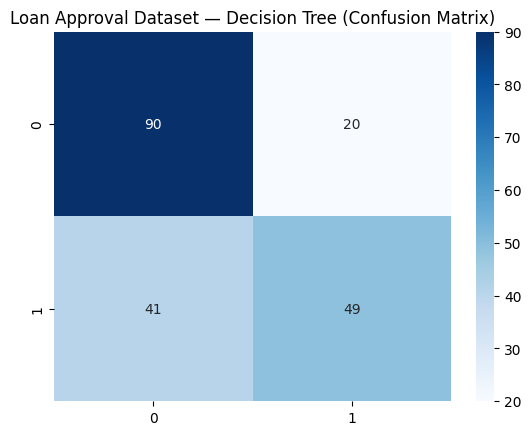

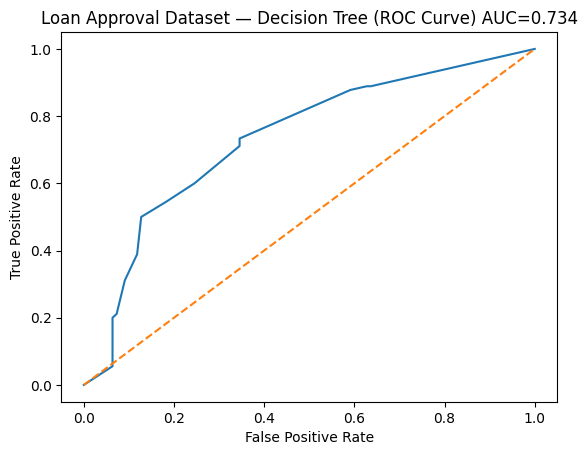


========== Loan Approval Dataset — Random Forest ==========
              precision    recall  f1-score   support

           0       0.73      0.77      0.75       110
           1       0.70      0.64      0.67        90

    accuracy                           0.71       200
   macro avg       0.71      0.71      0.71       200
weighted avg       0.71      0.71      0.71       200



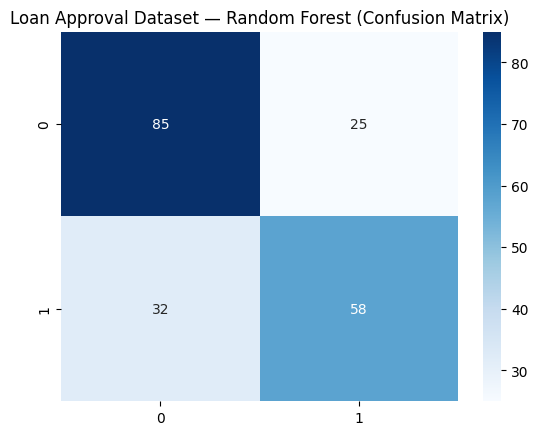

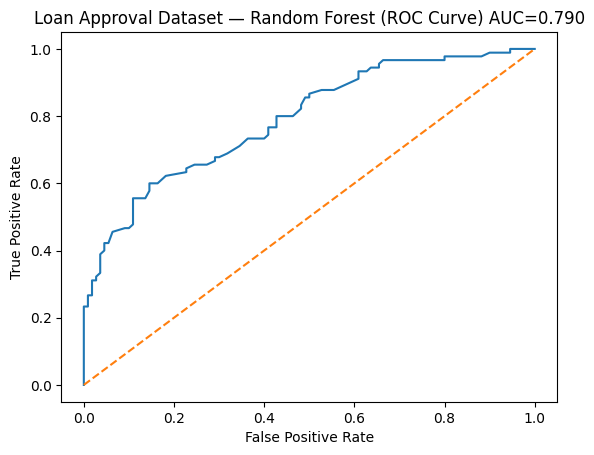

In [25]:
models = {
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(max_depth=6),
    "Random Forest": RandomForestClassifier(n_estimators=200)
}

for dataset_name, split in splits.items():
    print(f"\n\n=========== CLASSIFICATION MODELS ON: {dataset_name} ===========\n")

    for model_name, model in models.items():
        # Scale for distance-based models
        if model_name in ["KNN", "SVM (RBF)", "Logistic Regression"]:
            evaluate_classifier(
                model_name, model,
                split["X_train_scaled"], split["X_test_scaled"],
                split["y_train"], split["y_test"],
                dataset_name
            )
        else:
            evaluate_classifier(
                model_name, model,
                split["X_train"], split["X_test"],
                split["y_train"], split["y_test"],
                dataset_name
            )